# Setup de Librerias

In [1]:
# For calculation
import numpy as np
import os

# For visualization
import matplotlib.pyplot as plt
from skimage import io, color, filters, measure, morphology
import seaborn as sns

# Funciones a Utilizar

Matriz de Confusion

In [2]:
def plot_confusion_matrix(C):
    """
    Plot a confusion matrix using seaborn.

    Parameters:
        C (numpy.ndarray): A 2D numpy array representing the confusion matrix.
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(C, annot=True, fmt='.0f', cmap='Blues', cbar=False)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

Image Reading

In [3]:
def num2fixstr(x,d):
    # input: (21,5)
    # output: '00021'
    st = '%0*d' % (d,x)
    return st

def build_filename(prefix,num_class,digits_class,num_img,digits_img,sep='_'):
  return prefix + num2fixstr(num_class,digits_class) + sep + num2fixstr(num_img,digits_img) + '.png'

def imageload(prefix,num_class,digits_class,num_img,digits_img,sep='_',echo='off'):
  st   = build_filename(prefix,num_class,digits_class,num_img,digits_img,sep)
  if echo == 'on':
    print('loading image '+st+'...')
  img    = plt.imread(st)
  return img

Segmentación de Otsu

In [5]:
def segment_otsu(image_path, invert=False):
    """Read an image and segment it using Otsu's thresholding method.

    After thresholding, only the largest connected blob is kept to
    remove noise (see `keep_largest_blob`).

    Parameters
    ----------
    image_path : str
        Path to the image file.
    invert : bool
        If True, foreground is treated as pixels BELOW the threshold
        (useful when letters are dark on a light background).

    Returns
    -------
    gray : ndarray
        The original image in grayscale.
    binary : ndarray (bool)
        The segmented (binarized) image, with only the largest blob retained.
    threshold : float
        The threshold value chosen automatically by Otsu's method.
    """
    img = io.imread(image_path)
    gray = color.rgb2gray(img) if img.ndim == 3 else img

    threshold = filters.threshold_otsu(gray)
    binary = gray < threshold if invert else gray > threshold
    binary = keep_largest_blob(binary)

    return gray, binary, threshold

Limpieza de ruido: conservar el blob de mayor área

In [4]:
def keep_largest_blob(binary):
    """Remove noise from a binary image, keeping only the largest connected blob.

    Labels every connected component in the binary image, measures each
    component's area, and returns a binary mask containing only the
    component with the largest area.

    Parameters
    ----------
    binary : ndarray (bool)
        The segmented (binarized) image, e.g. the output of `segment_otsu`.

    Returns
    -------
    cleaned : ndarray (bool)
        Binary mask with only the largest-area blob retained.
    """
    labels = measure.label(binary)

    if labels.max() == 0:
        return binary

    areas = np.bincount(labels.ravel())
    areas[0] = 0  # ignore the background label
    largest_label = np.argmax(areas)

    return labels == largest_label

Mostrar Segmentacion

In [6]:
def show_segmentation(image_path, invert=False):
    """Segment an image with Otsu's method and display original vs. result."""
    gray, binary, threshold = segment_otsu(image_path, invert=invert)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(gray, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(binary, cmap="gray")
    axes[1].set_title(f"Otsu segmentation (t={threshold:.3f})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    return binary

Rellenar Agujeros

In [7]:
def fill_holes(binary_image):
    """
    Fill holes in a binary image.
    A hole is defined as a background region that is surrounded by foreground pixels.

    Parameters:
        binary_image (numpy.ndarray): A 2D binary NumPy array (0s and 1s).

    Returns:
        numpy.ndarray: Binary image with holes filled.
    """
    # Ensure input is binary (0 and 1 only)
    binary_image = (binary_image > 0).astype(np.uint8)

    # Create a padded version of the image to handle boundary cases
    padded = np.pad(binary_image, pad_width=1, mode='constant', constant_values=0)

    # Create a mask for background areas
    filled = np.zeros_like(padded, dtype=np.uint8)
    filled[0, 0] = 1  # Start flood-fill from the top-left corner

    # Structuring element for 4-connectivity (up, down, left, right)
    shifts = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    # Flood-fill algorithm
    while True:
        new_filled = filled.copy()
        for dx, dy in shifts:
            new_filled |= np.roll(filled, shift=dx, axis=0)
            new_filled |= np.roll(filled, shift=dy, axis=1)

        # Only allow propagation where the original padded image is background
        new_filled &= (padded == 0)

        if np.array_equal(filled, new_filled):
            break  # Stop when no new changes
        filled = new_filled

    # The holes are the complement of the flooded region inside the padded area
    holes_filled = np.where(filled[1:-1, 1:-1] == 0, 1, binary_image)

    return holes_filled

Area Normalizada

In [8]:
def NormalizedArea(S,echo='off'):

  if len(S.shape)>2:
    S = S[:,:,0]

  # If image has multiple channels (RGBA), use the first one for segmentation
  R = S>0                 # Binary image of the segmentation


  Rf = fill_holes(R).astype(int) # filled region (with no holes)

  # Area
  A  = np.sum(R)
  Af = np.sum(Rf)


  # Normalized area
  if Af == 0: # Avoid division by zero if width or height is 0
      a = 0.0
  else:
      a = A/Af

  if echo=='on':
    implot = plt.imshow(R,cmap='gray')
    print('normalized area = '+str(a))
  return a

Cerrar brechas del contorno

In [9]:
def close_gaps(binary_image, radius=3):
    """Morphologically close small gaps in a binary image's outline.

    Some fonts (especially distressed/grunge styles, seen in the testing
    set's P's) leave the bowl of a P, or the loop of an @, with a hairline
    break in its outline. That break lets `fill_holes`' flood fill leak
    in from the background, so `NormalizedArea` reports no hole at all
    (area == 1.0) even though the letter visually has one. Closing
    (dilation followed by erosion) bridges gaps up to about `2 * radius`
    pixels wide before the hole check runs.

    Parameters
    ----------
    binary_image : ndarray
        Binary (or boolean) image to close.
    radius : int
        Radius of the disk structuring element used for closing.

    Returns
    -------
    ndarray (bool)
        Closed binary image.
    """
    return morphology.closing(binary_image > 0, morphology.disk(radius))

Clasificación por área normalizada: P, @ vs. N, M, U

In [10]:
def classify_by_normalized_area(S, threshold=0.95):
    """Classify a segmented character as 'P o @' or 'N, M o U' by normalized area.

    P and @ each enclose a background region (a hole), so filling that hole
    increases their area and pushes the normalized area below 1. N, M and U
    have no holes, so their normalized area stays close to 1.

    Parameters
    ----------
    S : ndarray
        Segmented (binarized) character image, e.g. the output of `segment_otsu`.
    threshold : float
        Normalized area cutoff. Values below this are classified as 'P o @'.

    Returns
    -------
    str
        'P o @' if the normalized area is below `threshold`, otherwise 'N, M o U'.
    """
    a = NormalizedArea(S)
    return 'P o @' if a < threshold else 'N, M o U'

Excentricidad: diferenciar P de @

In [11]:
def Eccentricity(S, echo='off'):
  """Compute the eccentricity of a segmented character's filled region.

  Used to tell P from @: P is a tall, narrow stem-and-bowl shape (high
  eccentricity), while @ is close to circular (low eccentricity).

  Parameters
  ----------
  S : ndarray
      Segmented (binarized) character image, e.g. the output of `segment_otsu`.

  Returns
  -------
  float
      Eccentricity of the filled region's best-fit ellipse, in [0, 1).
      0 is a circle, values closer to 1 are more elongated.
  """
  if len(S.shape) > 2:
    S = S[:, :, 0]

  R = S > 0                      # Binary image of the segmentation
  Rf = fill_holes(R).astype(int) # filled region (with no holes)

  props = measure.regionprops(Rf)
  e = props[0].eccentricity if props else 0.0

  if echo == 'on':
    implot = plt.imshow(Rf, cmap='gray')
    print('eccentricity = ' + str(e))

  return e

Erosión 3x3

In [12]:
def erode3x3(binary_image):
    """Erode a binary image with a 3x3 structuring element.

    Erosion shrinks the foreground, which helps separate strokes that
    would otherwise touch or blur together for some fonts (e.g. where a
    diagonal stroke of an M or N grazes a vertical stroke), so scanline
    crossing counts stay more reliable across fonts.

    Parameters
    ----------
    binary_image : ndarray
        Binary (or boolean) image to erode.

    Returns
    -------
    ndarray (bool)
        Eroded binary image.
    """
    footprint = np.ones((3, 3), dtype=bool)
    return morphology.erosion(binary_image > 0, footprint)

Esqueletización

In [13]:
def skeletonize_binary(binary_image):
    """Reduce a binary image's foreground to its 1-pixel-wide skeleton.

    Unlike erosion, skeletonization thins every stroke down to a single
    pixel regardless of its original width, so scanline crossing counts
    stop depending on how thick or thin a particular font's strokes are.

    Parameters
    ----------
    binary_image : ndarray
        Binary (or boolean) image to skeletonize.

    Returns
    -------
    ndarray (bool)
        Skeletonized binary image.
    """
    return morphology.skeletonize(binary_image > 0)

In [14]:
def count_neighbors(binary_image):
  """Count, for every foreground pixel, how many of its 8 neighbours are
  also foreground (used to find skeleton endpoints, which have exactly 1)."""
  padded = np.pad(binary_image.astype(np.uint8), 1)
  counts = np.zeros_like(padded, dtype=np.uint8)
  for dy in (-1, 0, 1):
    for dx in (-1, 0, 1):
      if dy == 0 and dx == 0:
        continue
      counts += np.roll(np.roll(padded, dy, axis=0), dx, axis=1)
  return counts[1:-1, 1:-1] * binary_image


def prune_skeleton_spurs(skeleton, min_branch_length=20):
  """Remove short spurious branches ('spurs') from a skeleton.

  Skeletonization often leaves tiny 1-pixel-wide branches sticking out
  near stroke junctions or rounded corners (e.g. where a serif meets a
  straight stroke), which can add a spurious extra scanline crossing.
  This repeatedly strips skeleton endpoints (pixels with exactly 1
  neighbour) `min_branch_length` times, which fully erases any branch
  shorter than that while only shortening longer branches from their tips.

  Parameters
  ----------
  skeleton : ndarray (bool)
      Skeletonized binary image, e.g. the output of `skeletonize_binary`.
  min_branch_length : int
      Branches shorter than this many pixels are removed.

  Returns
  -------
  ndarray (bool)
      Pruned skeleton.
  """
  pruned = skeleton.copy()
  for _ in range(min_branch_length):
    endpoints = pruned & (count_neighbors(pruned) == 1)
    if not endpoints.any():
      break
    pruned = pruned & ~endpoints
  return pruned

Cruce de líneas por barrido: diferenciar M, N y U

In [15]:
def max_scanline_crossings(binary_image):
  """Count, for each row of a binary image, how many separate foreground
  runs ('lines') it crosses when swept left to right, and return the
  largest count found across all rows.

  Parameters
  ----------
  binary_image : ndarray (bool)
      Preprocessed (eroded or skeletonized) binary image.

  Returns
  -------
  int
      Maximum number of line crossings found in any single row.
  """
  max_lines = 0
  for row in range(binary_image.shape[0]):
    line = binary_image[row, :]

    # count rising edges (background -> foreground) as line crossings
    crossings = int(np.sum(line[1:] & ~line[:-1]))
    if line.size and line[0]:
      crossings += 1

    max_lines = max(max_lines, crossings)

  return max_lines


def crossings_to_letter(max_lines):
  """Map a maximum scanline crossing count to 'M', 'N' or 'U'."""
  if max_lines >= 4:
    return 'M'
  elif max_lines == 3:
    return 'N'
  else:
    return 'U'


def classify_by_scanlines_erosion(S, echo='off'):
  """Classify a segmented character as 'M', 'N' or 'U' by counting scanline
  crossings (`max_scanline_crossings`) on a 3x3-eroded version of the image
  (`erode3x3`). M has 4 legs, N has 3, and U has 2.

  Parameters
  ----------
  S : ndarray
      Segmented (binarized) character image, e.g. the output of `segment_otsu`.
  echo : str
      If 'on', prints the maximum crossing count found.

  Returns
  -------
  str
      'M' if the maximum crossing count is 4 or more, 'N' if it is 3,
      otherwise 'U'.
  """
  if len(S.shape) > 2:
    S = S[:, :, 0]

  max_lines = max_scanline_crossings(erode3x3(S > 0))

  if echo == 'on':
    print('max scanline crossings (erosion) = ' + str(max_lines))

  return crossings_to_letter(max_lines)


def classify_by_scanlines_skeleton(S, min_branch_length=20, echo='off'):
  """Classify a segmented character as 'M', 'N' or 'U' by counting scanline
  crossings (`max_scanline_crossings`) on a skeletonized version of the
  image (`skeletonize_binary`), pruned of short spurious branches
  (`prune_skeleton_spurs`). M has 4 legs, N has 3, and U has 2.

  Parameters
  ----------
  S : ndarray
      Segmented (binarized) character image, e.g. the output of `segment_otsu`.
  min_branch_length : int
      Passed through to `prune_skeleton_spurs`.
  echo : str
      If 'on', prints the maximum crossing count found.

  Returns
  -------
  str
      'M' if the maximum crossing count is 4 or more, 'N' if it is 3,
      otherwise 'U'.
  """
  if len(S.shape) > 2:
    S = S[:, :, 0]

  skeleton = prune_skeleton_spurs(skeletonize_binary(S > 0), min_branch_length)
  max_lines = max_scanline_crossings(skeleton)

  if echo == 'on':
    print('max scanline crossings (skeleton) = ' + str(max_lines))

  return crossings_to_letter(max_lines)

# Entrenamiento

In [16]:
!mkdir seg_training

A subdirectory or file seg_training already exists.


Guardar imágenes segmentadas

In [17]:
def save_segmentations(input_dir, output_dir=None, invert=False):
    """Segment every image in `input_dir` and save the results to `output_dir`.

    Works on any folder of character images (e.g. `training/` or
    `testing/`), regardless of how many images or classes it holds:
    every file already present in `input_dir` is segmented and saved, so
    there is no assumption about class/image counts or numbering.

    Each output file keeps the same filename as its corresponding input
    image, so `seg_testing/char_04_062.png` is the segmentation of
    `testing/char_04_062.png`.

    Parameters
    ----------
    input_dir : str
        Folder containing the original images to segment.
    output_dir : str or None
        Folder where segmented images are saved (created if it doesn't
        exist). Defaults to `seg_<basename of input_dir>`, e.g.
        `training` -> `seg_training`, `testing` -> `seg_testing`.
    invert : bool
        Passed through to `segment_otsu`.

    Returns
    -------
    str
        The output directory used.
    """
    if output_dir is None:
        output_dir = 'seg_' + os.path.basename(os.path.normpath(input_dir))

    os.makedirs(output_dir, exist_ok=True)

    for filename in sorted(os.listdir(input_dir)):
        image_path = os.path.join(input_dir, filename)
        _, binary, _ = segment_otsu(image_path, invert=invert)

        output_path = os.path.join(output_dir, filename)
        io.imsave(output_path, (binary * 255).astype(np.uint8))

    return output_dir

In [18]:
save_segmentations("training")

'seg_training'

Histograma de excentricidad: P vs. @

In [19]:
def plot_eccentricity_histogram(training_dir="training", char_prefix="char_",
                                 p_class=4, at_class=5, digits_class=2,
                                 num_images=50, digits_img=3, sep='_',
                                 invert=False, bins=20):
    """Plot a histogram of eccentricity values for the P and @ training images.

    Used to visually pick a good threshold for a P-vs-@ classifier built on
    top of `Eccentricity`: a cutoff placed where the two histograms overlap
    least should generalize well across fonts.

    Parameters
    ----------
    training_dir : str
        Folder containing the original training images.
    char_prefix : str
        Filename prefix before the zero-padded class number.
    p_class : int
        Class number for the letter P.
    at_class : int
        Class number for the letter @.
    digits_class, num_images, digits_img, sep :
        Passed through to `build_filename`, matching `imageload`'s naming
        convention.
    invert : bool
        Passed through to `segment_otsu`.
    bins : int
        Number of histogram bins.

    Returns
    -------
    tuple of lists
        (p_eccentricities, at_eccentricities)
    """
    def eccentricities_for_class(num_class):
        values = []
        for num_img in range(1, num_images + 1):
            filename = build_filename(char_prefix, num_class, digits_class, num_img, digits_img, sep)
            image_path = os.path.join(training_dir, filename)
            _, binary, _ = segment_otsu(image_path, invert=invert)
            values.append(Eccentricity(binary))
        return values

    p_values = eccentricities_for_class(p_class)
    at_values = eccentricities_for_class(at_class)

    plt.figure(figsize=(6, 4))
    plt.hist(p_values, bins=bins, alpha=0.6, label='P')
    plt.hist(at_values, bins=bins, alpha=0.6, label='@')
    plt.xlabel('eccentricity')
    plt.ylabel('count')
    plt.title('Eccentricity distribution: P vs. @')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return p_values, at_values

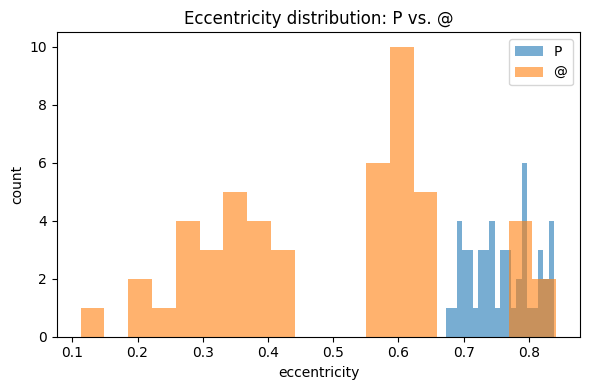

([0.7401477511905206,
  0.735539177744428,
  0.7625855396562173,
  0.7524506734039482,
  0.7060893512034802,
  0.7152701232572047,
  0.7242796083768132,
  0.712728889740007,
  0.7442997032514757,
  0.6922953089446214,
  0.693282320418958,
  0.7328955431170792,
  0.702583530345993,
  0.7110851574000325,
  0.691140992997097,
  0.8169047533382677,
  0.7913364694387525,
  0.8169589712469392,
  0.702394671882924,
  0.8079806532128797,
  0.7367167893540337,
  0.7585438693798227,
  0.7707034385381646,
  0.7710620000107044,
  0.7896046510721211,
  0.7624065021941783,
  0.6991575624621277,
  0.7895504080355288,
  0.7870361307512014,
  0.7821029917798491,
  0.7672128295721795,
  0.8312225224945087,
  0.7769804411500226,
  0.6952060317195518,
  0.7284297402346366,
  0.6725760290797118,
  0.7436880023684883,
  0.7911658276125861,
  0.7252388538979432,
  0.8305458781058445,
  0.8186865602159902,
  0.7903019414824658,
  0.8326752221561674,
  0.6812215291612908,
  0.8390203894246016,
  0.801493695706

In [20]:
plot_eccentricity_histogram(training_dir="seg_training", char_prefix="char_",
                            p_class=4, at_class=5, digits_class=2)

Se utilizará una excentricidad de 0.64 para determinar entre P y @

Arbol de desición del algoritmo:
![Arbol](arbol.png)

In [21]:
def classify_character(seg_image_path, area_threshold=0.95, eccentricity_threshold=0.64,
                        nmu_method='erosion', closing_radius=0):
    """Classify an already-segmented character image as 'N', 'M', 'U', 'P' or
    '@' following the decision tree in `arbol.png`.

    Expects `seg_image_path` to point to a binary image produced ahead of
    time by `save_segmentations` (e.g. under `seg_training/`), so no Otsu
    segmentation is redone here.

    1. Load the segmented image and binarize it (foreground = pixels > 0).
       If `closing_radius` > 0, close small outline gaps first
       (`close_gaps`) so a broken bowl/loop (common in distressed fonts)
       still registers as an enclosed hole.
    2. Compute the normalized area (`NormalizedArea`). Above
       `area_threshold` the letter has no holes -> N, M or U; at or below
       it, the letter encloses a hole -> P or @.
    3a. N/M/U branch: count scanline crossings using either the eroded
        (`classify_by_scanlines_erosion`) or skeletonized
        (`classify_by_scanlines_skeleton`) image, selected by
        `nmu_method`: 4 lines -> M, 3 -> N, 2 -> U.
    3b. P/@ branch: compute the eccentricity of the filled region
        (`Eccentricity`). Above `eccentricity_threshold` -> P (tall,
        narrow stem-and-bowl); otherwise -> @ (closer to circular).

    Note: `arbol.png` draws the eccentricity branch as >0.64 -> @, but the
    eccentricity histogram (P: ~0.67-0.84, @: mostly well under 0.64,
    long tail up) shows P is the more elongated letter, so this function
    routes >`eccentricity_threshold` to 'P' to match the measured data.

    Parameters
    ----------
    seg_image_path : str
        Path to an already-segmented (binary) character image.
    area_threshold : float
        Normalized-area cutoff separating {N, M, U} from {P, @}.
    eccentricity_threshold : float
        Eccentricity cutoff separating P from @.
    nmu_method : str
        Which N/M/U branch classifier to use: 'erosion' or 'skeleton'.
    closing_radius : int
        If > 0, close outline gaps (`close_gaps`) before computing the
        normalized area, to recover holes broken by distressed fonts.

    Returns
    -------
    str
        One of 'N', 'M', 'U', 'P', '@'.
    """
    binary = io.imread(seg_image_path) > 0
    area_input = close_gaps(binary, closing_radius) if closing_radius > 0 else binary

    if NormalizedArea(area_input) > area_threshold:
        classify_nmu = classify_by_scanlines_skeleton if nmu_method == 'skeleton' else classify_by_scanlines_erosion
        return classify_nmu(binary)

    return 'P' if Eccentricity(binary) > eccentricity_threshold else '@'

In [22]:
classify_character("seg_training/char_01_001.png")

'N'

Evaluación: precisión y matriz de confusión

In [23]:
import pandas as pd

def evaluate_classifier(seg_dir="seg_training", char_prefix="char_", sep='_',
                         class_labels=None, area_threshold=0.95, eccentricity_threshold=0.64,
                         nmu_method='erosion', closing_radius=0):
    """Evaluate `classify_character` against a folder of segmented images.

    Each filename is expected to follow the Image Reading convention
    (`char_prefix` + zero-padded class number + `sep` + zero-padded image
    number + '.png'), so the true label can be read straight from the
    filename. Prints the overall accuracy and a confusion matrix (rows =
    true label, columns = predicted label), then returns both.

    Parameters
    ----------
    seg_dir : str
        Folder containing the already-segmented images to evaluate.
    char_prefix : str
        Filename prefix before the zero-padded class number.
    sep : str
        Separator between the class and image numbers in the filename.
    class_labels : dict or None
        Maps class number -> letter. Defaults to
        {1: 'N', 2: 'M', 3: 'U', 4: 'P', 5: '@'}.
    area_threshold : float
        Passed through to `classify_character`.
    eccentricity_threshold : float
        Passed through to `classify_character`.
    nmu_method : str
        Passed through to `classify_character`: 'erosion' or 'skeleton',
        letting you compare the two N/M/U branch classifiers.
    closing_radius : int
        Passed through to `classify_character`.

    Returns
    -------
    tuple
        (accuracy, confusion_matrix) where confusion_matrix is a
        pandas DataFrame indexed and columned by letter.
    """
    if class_labels is None:
        class_labels = {1: 'N', 2: 'M', 3: 'U', 4: 'P', 5: '@'}

    labels = [class_labels[k] for k in sorted(class_labels)]
    confusion = pd.DataFrame(0, index=labels, columns=labels)

    filenames = sorted(f for f in os.listdir(seg_dir) if f.startswith(char_prefix))

    correct = 0
    for filename in filenames:
        num_class = int(filename[len(char_prefix):].split(sep)[0])
        true_label = class_labels[num_class]

        image_path = os.path.join(seg_dir, filename)
        predicted_label = classify_character(image_path, area_threshold=area_threshold,
                                              eccentricity_threshold=eccentricity_threshold,
                                              nmu_method=nmu_method, closing_radius=closing_radius)

        confusion.loc[true_label, predicted_label] += 1
        correct += (predicted_label == true_label)

    total = len(filenames)
    accuracy = correct / total if total else 0.0

    print(f'nmu_method = {nmu_method}, closing_radius = {closing_radius}')
    print(f'accuracy = {accuracy:.3f} ({correct}/{total})')
    print(confusion)

    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
                cbar=False, square=True)
    plt.xlabel('predicted')
    plt.ylabel('true')
    plt.title(f'Confusion matrix ({nmu_method}, closing={closing_radius})')
    plt.tight_layout()
    plt.show()

    return accuracy, confusion

nmu_method = erosion, closing_radius = 0
accuracy = 0.840 (210/250)
    N   M   U   P   @
N  47   3   0   0   0
M  13  37   0   0   0
U  12   1  36   0   1
P   3   0   1  46   0
@   4   0   0   2  44


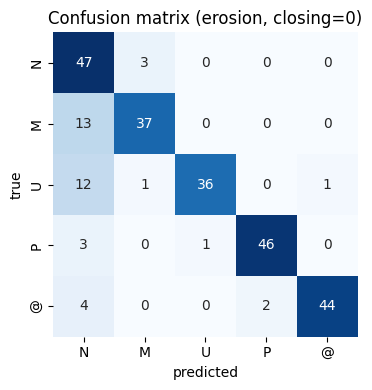

nmu_method = skeleton, closing_radius = 0
accuracy = 0.940 (235/250)
    N   M   U   P   @
N  46   4   0   0   0
M   0  50   0   0   0
U   0   0  49   0   1
P   0   0   4  46   0
@   4   0   0   2  44


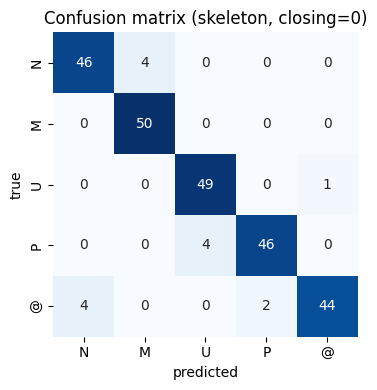

nmu_method = erosion, closing_radius = 3
accuracy = 0.840 (210/250)
    N   M   U   P   @
N  46   3   0   0   1
M  13  37   0   0   0
U   9   1  34   0   6
P   1   0   0  49   0
@   0   0   0   6  44


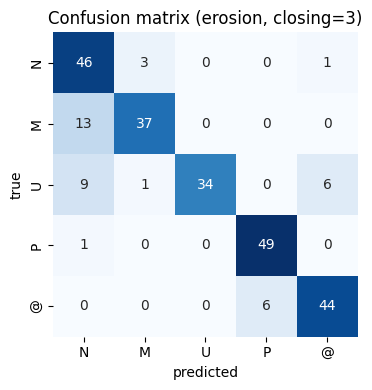

nmu_method = skeleton, closing_radius = 3
accuracy = 0.928 (232/250)
    N   M   U   P   @
N  45   4   0   0   1
M   0  50   0   0   0
U   0   0  44   0   6
P   0   0   1  49   0
@   0   0   0   6  44


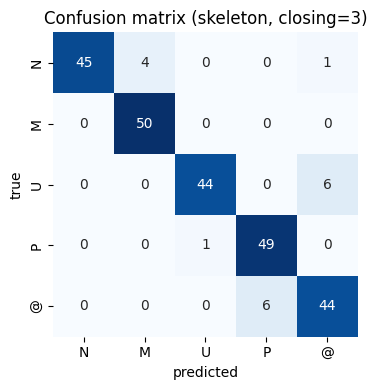

(0.928,
     N   M   U   P   @
 N  45   4   0   0   1
 M   0  50   0   0   0
 U   0   0  44   0   6
 P   0   0   1  49   0
 @   0   0   0   6  44)

In [30]:
evaluate_classifier("seg_training", nmu_method='erosion', closing_radius=0)
evaluate_classifier("seg_training", nmu_method='skeleton', closing_radius=0)
evaluate_classifier("seg_training", nmu_method='erosion', closing_radius=3)
evaluate_classifier("seg_training", nmu_method='skeleton', closing_radius=3)

# Testing

In [25]:
!mkdir seg_testing

A subdirectory or file seg_testing already exists.


In [26]:
save_segmentations("testing")

'seg_testing'

nmu_method = skeleton, closing_radius = 0
accuracy = 0.728 (91/125)
    N   M   U   P   @
N  15   0  10   0   0
M   0  19   6   0   0
U   0   0  25   0   0
P   3   0  11  11   0
@   0   4   0   0  21


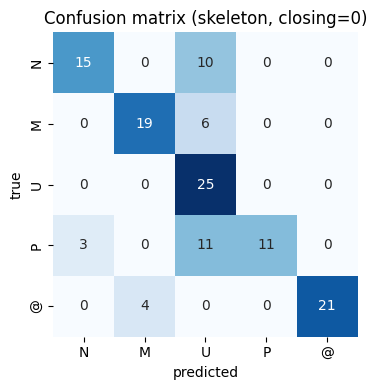

nmu_method = skeleton, closing_radius = 3
accuracy = 0.752 (94/125)
    N   M   U   P   @
N  15   0  10   0   0
M   0  19   6   0   0
U   0   0  24   1   0
P   3   0  11  11   0
@   0   0   0   0  25


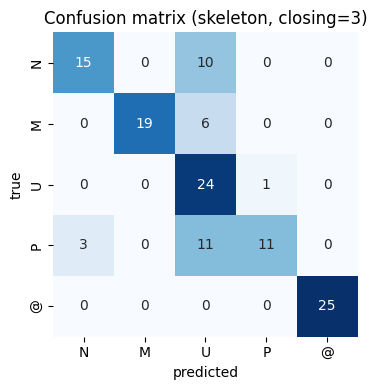

(0.752,
     N   M   U   P   @
 N  15   0  10   0   0
 M   0  19   6   0   0
 U   0   0  24   1   0
 P   3   0  11  11   0
 @   0   0   0   0  25)

In [27]:
evaluate_classifier("seg_testing", nmu_method='skeleton', closing_radius=0)
evaluate_classifier("seg_testing", nmu_method='skeleton', closing_radius=3)